##  Basic Library imports

In [2]:
import os
import pandas as pd 

from utils import download_images

##  Read Train Dataset

In [15]:
DATASET_FOLDER = '../dataset/train_split'
IMAGE_DIR = '../images/train_part3'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part3.csv'))
# val_set = pd.read_csv(os.path.join(DATASET_FOLDER, '../dataset/val_split.csv'))

In [5]:
download_images(train_set['image_link'], IMAGE_DIR)

  0%|          | 1/19611 [00:13<73:39:03, 13.52s/it]

Remote end closed connection without response
<urlopen error [Errno 101] Network is unreachable>Warning: Not able to download - https://m.media-amazon.com/images/I/61AfhCxazvL.jpg
<urlopen error [Errno 101] Network is unreachable>

<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
Remote end closed connection without response
Remote end closed connection without response
Remote end closed connection without response
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name re

Process ForkPoolWorker-195:
  0%|          | 2/19611 [57:33<9405:52:53, 1726.82s/it]Process ForkPoolWorker-193:
Process ForkPoolWorker-198:
Process ForkPoolWorker-178:
Process ForkPoolWorker-173:
Process ForkPoolWorker-171:
Process ForkPoolWorker-121:
Process ForkPoolWorker-138:



KeyboardInterrupt: 

In [16]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, IMAGE_DIR, download_images)
print(f"Missing images downloaded: {len(missing)}")



0it [00:00, ?it/s]

Missing images downloaded: 0


In [ ]:
assert len(os.listdir('../images/train_part1')) > 0

In [17]:
train_set['basename'] = train_set['image_link'].astype(str).str.strip().apply(os.path.basename)
duplicates = train_set[train_set.duplicated('basename', keep=False)]

to_remove = []
for basename, group in duplicates.groupby('basename'):
    to_remove.extend(group.index.tolist()[1:]) 


train_set_clean = train_set.drop(to_remove).drop(columns=['basename'])
print(f"Rows before: {len(train_set)}, after removing multi-price images: {len(train_set_clean)}")

train_set_clean.to_csv(os.path.join(DATASET_FOLDER, 'part1.csv'), index=False)
del train_set, duplicates, to_remove

Rows before: 19984, after removing multi-price images: 19788


In [18]:
print("Total rows in CSV:", len(train_set_clean))
print("Rows with null image_link:", train_set_clean['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set_clean['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set_clean['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set_clean['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set_clean[train_set_clean['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 19788
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 19788
Unique image filenames (basenames): 19788
Files in image directory: 19591
No duplicate basenames found.


####  There are some rows that do not have an image at all.

Let's remove them

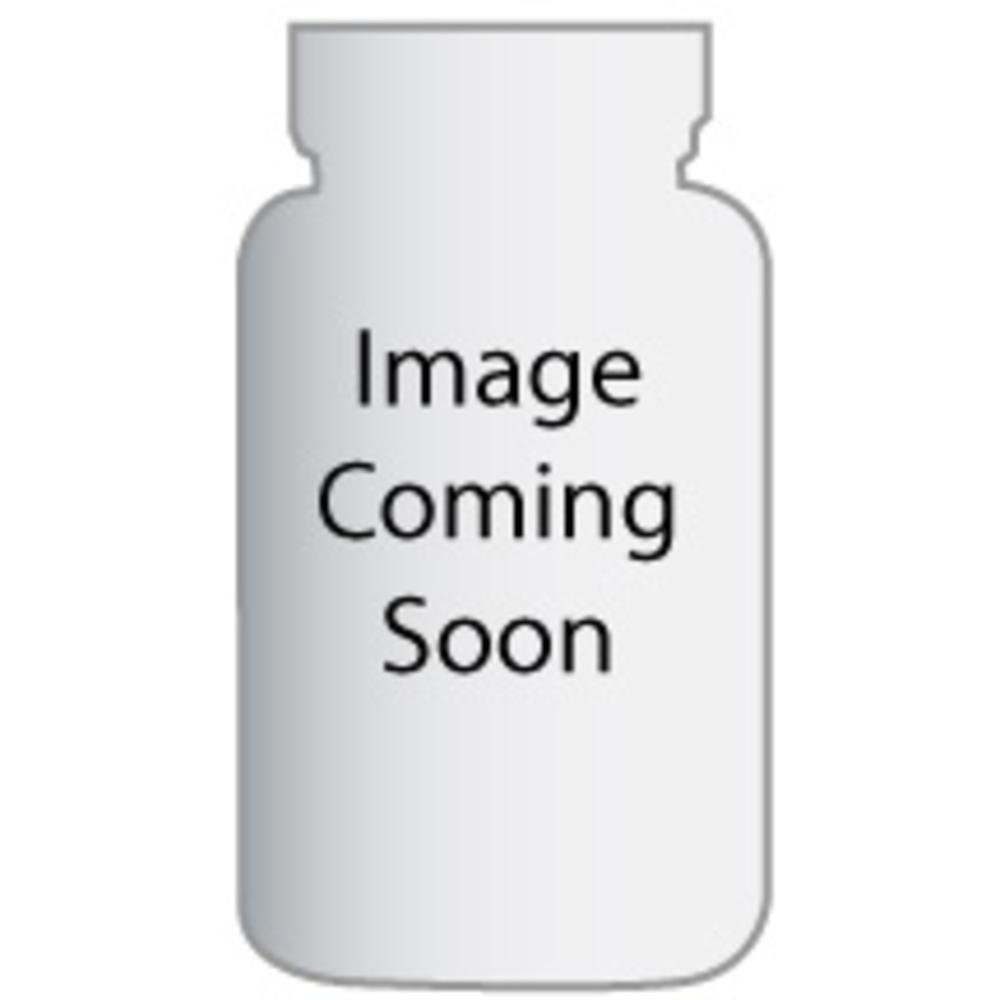

In [16]:
from IPython.display import Image, display

image_path = os.path.join('../images/train_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [ ]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 16 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 10 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 16 rows removed.


#### Rename to ID

In [19]:
basename_to_id = dict(zip(train_set_clean['image_link'].astype(str).str.strip().apply(os.path.basename), train_set_clean['sample_id'].astype(str)))

renamed = 0
for fname in os.listdir(IMAGE_DIR):
    if fname in basename_to_id:
        new_name = f"{basename_to_id[fname]}.jpg"
        src = os.path.join(IMAGE_DIR, fname)
        dst = os.path.join(IMAGE_DIR, new_name)
        if src != dst:
            os.rename(src, dst)
            print(f"Renamed {fname} -> {new_name}")
            renamed += 1
print(f"Total images renamed: {renamed}")

Renamed 81DcqQoBHEL.jpg -> 202209.jpg
Renamed 51gaT4JO5ML.jpg -> 133520.jpg
Renamed 71jxLTJfnaL.jpg -> 60979.jpg
Renamed 610HGoNUxRL.jpg -> 243960.jpg
Renamed 810P9ZMpdvL.jpg -> 207233.jpg
Renamed 71AzSJ7uXsL.jpg -> 84802.jpg
Renamed 61zMvw6uG0L.jpg -> 109414.jpg
Renamed 61JzEvHJwqL.jpg -> 47587.jpg
Renamed 61M5sg+39UL.jpg -> 41078.jpg
Renamed 61VClSPw0NL.jpg -> 56236.jpg
Renamed 81Tu6O2gJvL.jpg -> 28052.jpg
Renamed 71Z3De9axQL.jpg -> 265616.jpg
Renamed 71YdgNnd+pL.jpg -> 63147.jpg
Renamed 71a8G3RKfqL.jpg -> 258297.jpg
Renamed 41QXOpkeqIL.jpg -> 141815.jpg
Renamed 51I6GbNwmVL.jpg -> 18377.jpg
Renamed 51Wl6uRg8tL.jpg -> 180369.jpg
Renamed 81frIkadZ0L.jpg -> 6691.jpg
Renamed 81oz-UlZk7L.jpg -> 146566.jpg
Renamed 71iywhRj4fL.jpg -> 134128.jpg
Renamed 51dTQ6iz98L.jpg -> 277156.jpg
Renamed 51i4FcpNEPL.jpg -> 57388.jpg
Renamed 61WhUV92ndL.jpg -> 236534.jpg
Renamed 81ryjbxaPaL.jpg -> 58709.jpg
Renamed 91UPSboYoJL.jpg -> 223323.jpg
Renamed 71cZ4Ig04zL.jpg -> 134427.jpg
Renamed 81yXfluBkXL.jpg 

In [20]:
import zipfile

images_dir = '../images/train_part3'
zip_path = '../train_part3.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../train_part3.zip


In [ ]:
# rm -rf ../images

##  Read Val Dataset

In [3]:
DATASET_FOLDER = '../dataset/val_split'
IMAGE_DIR = '../images/val_part3'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part3.csv'))

In [ ]:
download_images(train_set['image_link'], IMAGE_DIR)

 11%|█         | 533/4996 [00:34<02:22, 31.32it/s] 

<urlopen error [Errno -3] Temporary failure in name resolution>


 21%|██▏       | 1067/4996 [01:54<10:46,  6.08it/s]Process ForkPoolWorker-496:
Process ForkPoolWorker-493:
 31%|███       | 1534/4996 [1:02:33<2:21:10,  2.45s/it]Process ForkPoolWorker-494:
Process ForkPoolWorker-465:
Process ForkPoolWorker-458:
Process ForkPoolWorker-497:
Process ForkPoolWorker-455:
Process ForkPoolWorker-436:
Process ForkPoolWorker-488:
Process ForkPoolWorker-435:
Process ForkPoolWorker-492:
Process ForkPoolWorker-491:
Process ForkPoolWorker-409:
Process ForkPoolWorker-495:
Process ForkPoolWorker-482:
Process ForkPoolWorker-480:
Process ForkPoolWorker-484:
Process ForkPoolWorker-434:
Process ForkPoolWorker-485:
Process ForkPoolWorker-404:
Process ForkPoolWorker-479:
Process ForkPoolWorker-500:
Process ForkPoolWorker-474:
Process ForkPoolWorker-440:
Process ForkPoolWorker-457:
Process ForkPoolWorker-422:
Process ForkPoolWorker-447:
Process ForkPoolWorker-476:
Process ForkPoolWorker-470:
Process ForkPoolWorker-408:
Process ForkPoolWorker-415:
Process ForkPoolWorker-473

In [4]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, IMAGE_DIR, download_images)
print(f"Missing images downloaded: {len(missing)}")

Missing: 81IJOdVG+uL.jpg


100%|██████████| 1/1 [00:00<00:00, 16.30it/s]

Missing images downloaded: 1


In [5]:
train_set['basename'] = train_set['image_link'].astype(str).str.strip().apply(os.path.basename)
duplicates = train_set[train_set.duplicated('basename', keep=False)]

to_remove = []
for basename, group in duplicates.groupby('basename'):
    to_remove.extend(group.index.tolist()[1:]) 


train_set_clean = train_set.drop(to_remove).drop(columns=['basename'])
print(f"Rows before: {len(train_set)}, after removing multi-price images: {len(train_set_clean)}")

train_set_clean.to_csv(os.path.join(DATASET_FOLDER, 'part1.csv'), index=False)
del train_set, duplicates, to_remove

Rows before: 4996, after removing multi-price images: 4981


In [6]:
print("Total rows in CSV:", len(train_set_clean))
print("Rows with null image_link:", train_set_clean['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set_clean['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set_clean['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set_clean['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set_clean[train_set_clean['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 4981
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 4981
Unique image filenames (basenames): 4981
Files in image directory: 19591
No duplicate basenames found.


####  There are some rows that do not have an image at all.

Let's remove them

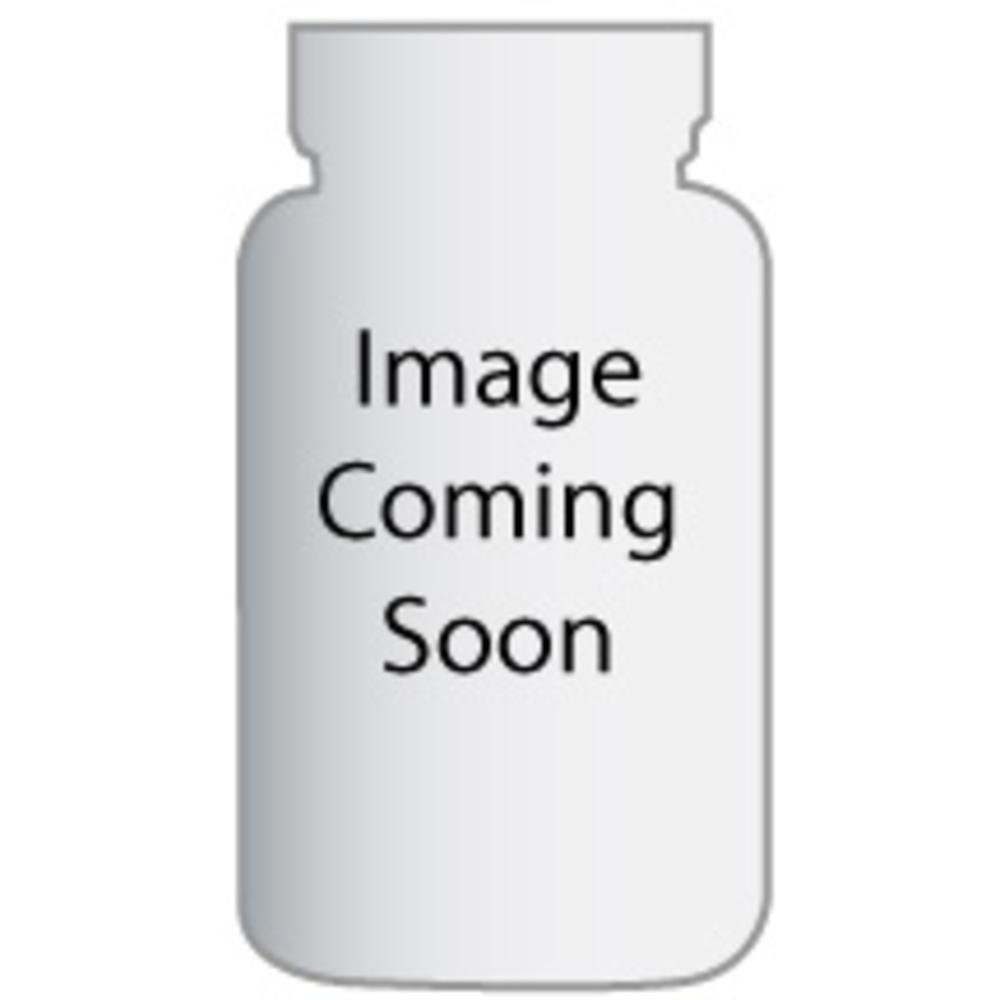

In [5]:
from IPython.display import Image, display

image_path = os.path.join('../images/val_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [6]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 4 rows removed.


In [7]:
basename_to_id = dict(zip(train_set_clean['image_link'].astype(str).str.strip().apply(os.path.basename), train_set_clean['sample_id'].astype(str)))

renamed = 0
for fname in os.listdir(IMAGE_DIR):
    if fname in basename_to_id:
        new_name = f"{basename_to_id[fname]}.jpg"
        src = os.path.join(IMAGE_DIR, fname)
        dst = os.path.join(IMAGE_DIR, new_name)
        if src != dst:
            os.rename(src, dst)
            print(f"Renamed {fname} -> {new_name}")
            renamed += 1
print(f"Total images renamed: {renamed}")

Renamed 81mOGnp1o1L.jpg -> 232019.jpg
Renamed 71S3Tnp4k7L.jpg -> 106457.jpg
Renamed 71W7uV0ub5L.jpg -> 193385.jpg
Renamed 61JSUFT59VL.jpg -> 225632.jpg
Renamed 21fuysqR2ML.jpg -> 155851.jpg
Renamed 71r00gDpFxL.jpg -> 37999.jpg
Renamed 8123JuEPfJL.jpg -> 184474.jpg
Renamed 51iKbDXOrNL.jpg -> 218871.jpg
Renamed 81piOOGd1CL.jpg -> 4148.jpg
Renamed 81K+xNgQIGL.jpg -> 206032.jpg
Renamed 412sZXjggaL.jpg -> 208060.jpg
Renamed 81uenbDF0-L.jpg -> 205286.jpg
Renamed 713Ccc2NNbL.jpg -> 28589.jpg
Renamed 61cGuV1Cm6L.jpg -> 184686.jpg
Renamed 71QWsvEbBHL.jpg -> 257873.jpg
Renamed 71qApusfJQS.jpg -> 236892.jpg
Renamed 71SHRpnLdGL.jpg -> 127905.jpg
Renamed 81e-nIZrwOL.jpg -> 172676.jpg
Renamed 91HszbFtFiL.jpg -> 53725.jpg
Renamed 61SYRMk7X3L.jpg -> 291104.jpg
Renamed 61-BFksDhQL.jpg -> 298413.jpg
Renamed 718E0BW4XkL.jpg -> 253481.jpg
Renamed 81UcmNK5fNL.jpg -> 148817.jpg
Renamed 71z4jFDsQjL.jpg -> 97943.jpg
Renamed 81O0ojwZcOL.jpg -> 18797.jpg
Renamed 71locZ1IJmL.jpg -> 52646.jpg
Renamed 71pLKCQ-IuL.

#### Save the folder as a ZIP File

In [8]:
import zipfile

images_dir = '../images/val_part3'
zip_path = '../val_part3.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../val_part3.zip
